#  **Environment Setup**

## Pip Install

In [20]:
!pip install datasets

#  **Import**

In [21]:
import datasets

In [22]:
!python --version

Python 3.11.7


In [23]:
datasets.__version__

'4.5.0'

#  **TinyStories Overview**

## 🟠 Dataset

In [24]:
from datasets import load_dataset

In [25]:
load_dataset?

Signature:
load_dataset(
    path: str,
    name: Optional[str] = None,
    data_dir: Optional[str] = None,
    data_files: Union[str, collections.abc.Sequence[str], collections.abc.Mapping[str, Union[str, collections.abc.Sequence[str]]], NoneType] = None,
    split: Union[str, datasets.splits.Split, list[str], list[datasets.splits.Split], NoneType] = None,
    cache_dir: Optional[str] = None,
    features: Optional[datasets.features.features.Features] = None,
    download_config: Optional[datasets.download.download_config.DownloadConfig] = None,
    download_mode: Union[datasets.download.download_manager.DownloadMode, str, NoneType] = None,
    verification_mode: Union[datasets.utils.info_utils.VerificationMode, str, NoneType] = None,
    keep_in_memory: Optional[bool] = None,
    save_infos: bool = False,
    revision: Union[datasets.utils.version.Version, str, NoneType] = None,
    token: Union[bool, str, NoneType] = None,
    streaming: bool = False,
    num_proc: Optional[int] = N

In [26]:
dataset = load_dataset("roneneldan/TinyStories")
dataset

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/roneneldan/TinyStories/resolve/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/TinyStories.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since roneneldan/TinyStories couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\hp\.cache\huggingface\datasets\roneneldan___tiny_stories\default\0.0.0\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64 (last modified on Sun Feb 22 21:39:58 2026).


DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

In [27]:
dataset.save_to_disk("tinystories_local")

Saving the dataset (0/4 shards):   0%|          | 0/2119719 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/21990 [00:00<?, ? examples/s]

In [28]:
dataset['train'], dataset['validation']

(Dataset({
     features: ['text'],
     num_rows: 2119719
 }),
 Dataset({
     features: ['text'],
     num_rows: 21990
 }))

In [29]:
dataset["train"][0]

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}

In [30]:
from pprint import pprint

pprint(dataset["train"][0]['text'])

('One day, a little girl named Lily found a needle in her room. She knew it '
 'was difficult to play with it because it was sharp. Lily wanted to share the '
 'needle with her mom, so she could sew a button on her shirt.\n'
 '\n'
 'Lily went to her mom and said, "Mom, I found this needle. Can you share it '
 'with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share '
 'the needle and fix your shirt."\n'
 '\n'
 "Together, they shared the needle and sewed the button on Lily's shirt. It "
 'was not difficult for them because they were sharing and helping each other. '
 'After they finished, Lily thanked her mom for sharing the needle and fixing '
 'her shirt. They both felt happy because they had shared and worked together.')


In [31]:
pprint(dataset['train'][0]['text'])

('One day, a little girl named Lily found a needle in her room. She knew it '
 'was difficult to play with it because it was sharp. Lily wanted to share the '
 'needle with her mom, so she could sew a button on her shirt.\n'
 '\n'
 'Lily went to her mom and said, "Mom, I found this needle. Can you share it '
 'with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share '
 'the needle and fix your shirt."\n'
 '\n'
 "Together, they shared the needle and sewed the button on Lily's shirt. It "
 'was not difficult for them because they were sharing and helping each other. '
 'After they finished, Lily thanked her mom for sharing the needle and fixing '
 'her shirt. They both felt happy because they had shared and worked together.')


## 🟠 Models

In [32]:
from transformers import AutoModelForCausalLM, AutoTokenizer  # Import model and tokenizer classes

# Load a pre-trained causal language model (TinyStories-33M)
model = AutoModelForCausalLM.from_pretrained('roneneldan/TinyStories-33M')

# Load a pre-trained tokenizer (GPT-Neo tokenizer is used instead of the TinyStories tokenizer)
tokenizer = AutoTokenizer.from_pretrained("EleutherAI/gpt-neo-125M")

# Define the initial text prompt
prompt = "One day, a little girl named"

# Tokenize the input text and convert it into tensor format
input_ids = tokenizer.encode(prompt, return_tensors="pt")

# Generate text based on the input, setting a max length and using greedy search (num_beams=1)
output = model.generate(input_ids, max_length=1000, num_beams=1)

# Decode the generated token IDs back into human-readable text
output_text = tokenizer.decode(output[0], skip_special_tokens=True)

# Pretty-print the generated text
print(100 * "_")
pprint(output_text)


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\httpx\_transports\default.py", line 101, in map_httpcore_exceptions
    yield
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\httpx\_transports\default.py", line 250, in handle_request
    resp = self._pool.handle_request(req)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\httpcore\_sync\connection_pool.py", line 256, in handle_request
    raise exc from None
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\httpcore\_sync\connection_pool.py", line 236, in handle_request
    response = connection.handle_request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\httpcore\_sync\connection.py", line 101, in handle_request
    raise exc
 

Loading weights:   0%|          | 0/56 [00:00<?, ?it/s]

    raise to_exc(exc) from exc
httpcore.ConnectError: [Errno 11001] getaddrinfo failed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\safetensors_conversion.py", line 117, in auto_conversion
    raise e
  File "c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\safetensors_conversion.py", line 96, in auto_conversion
    sha = get_conversion_pr_reference(api, pretrained_model_name_or_path, **cached_file_kwargs)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\hp\AppData\Local\Program

____________________________________________________________________________________________________
('One day, a little girl named Lily went to the park with her mom. They saw a '
 'big tree with a swing hanging from it. Lily wanted to play on the swing, but '
 'it was too high for her to reach.\n'
 '\n'
 'Lily\'s mom said, "Don\'t worry, I will help you." She picked her up and put '
 'her on the swing. Lily was so happy! She started to swing back and forth, '
 'higher and higher.\n'
 '\n'
 'As Lily was swinging, she saw a little boy named Tim. Tim was sad because he '
 'lost his toy. Lily stopped swinging and went to help Tim. She said, "Don\'t '
 'be sad, Tim. We will find your toy." They looked and looked, and finally, '
 'they found the toy under a bush. Tim was so happy, and he said, "Thank you, '
 'Lily!"\n'
 '\n'
 'Lily and Tim became good friends. They played together at the park every '
 'day. They always helped each other and had lots of fun. And they always '
 'remembered t

## 🟠 Others

### 🟡 Dataset Directory

In [33]:
dataset.cache_files

{'train': [{'filename': 'C:\\Users\\hp\\.cache\\huggingface\\datasets\\roneneldan___tiny_stories\\default\\0.0.0\\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64\\tiny_stories-train-00000-of-00004.arrow'},
  {'filename': 'C:\\Users\\hp\\.cache\\huggingface\\datasets\\roneneldan___tiny_stories\\default\\0.0.0\\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64\\tiny_stories-train-00001-of-00004.arrow'},
  {'filename': 'C:\\Users\\hp\\.cache\\huggingface\\datasets\\roneneldan___tiny_stories\\default\\0.0.0\\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64\\tiny_stories-train-00002-of-00004.arrow'},
  {'filename': 'C:\\Users\\hp\\.cache\\huggingface\\datasets\\roneneldan___tiny_stories\\default\\0.0.0\\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64\\tiny_stories-train-00003-of-00004.arrow'}],
 'validation': [{'filename': 'C:\\Users\\hp\\.cache\\huggingface\\datasets\\roneneldan___tiny_stories\\default\\0.0.0\\f54c09fd23315a6f9c86f9dc80f725de7d8f9c64\\tiny_stories-validation.arrow'}]}

### 🟡 HuggingFace Hub

In [34]:
## Install Hugging Face CLI explicitly

python -m pip install --upgrade huggingface_hub[cli]

SyntaxError: invalid syntax (2729608963.py, line 3)

In [ ]:
# after getting token from hugging face 
hf auth login

In [ ]:
from huggingface_hub import hf_hub_download

In [ ]:
hf_hub_download?

In [ ]:
repo_id = "roneneldan/TinyStories-8M"  
filename = "vocab.json"  

file_path = hf_hub_download(repo_id=repo_id, filename=filename, local_dir="/content/")

print(f"File downloaded to: {file_path}")

vocab.json: 0.00B [00:00, ?B/s]

File downloaded to: \content\vocab.json


In [ ]:
# for dataset
repo_id = "roneneldan/TinyStories"  
filename = "TinyStoriesV2-GPT4-valid.txt"  

file_path = hf_hub_download(repo_id=repo_id, filename=filename, repo_type="dataset")

print(f"File downloaded to: {file_path}")

TinyStoriesV2-GPT4-valid.txt:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

File downloaded to: /root/.cache/huggingface/hub/datasets--roneneldan--TinyStories/snapshots/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/TinyStoriesV2-GPT4-valid.txt


# **TinyStories-GPT4**

In [ ]:
dataset = load_dataset("skeskinen/TinyStories-GPT4")
dataset

data/train-00002-of-00008-9b868f59be94d8(…):   0%|          | 0.00/194M [00:00<?, ?B/s]

In [ ]:
dataset["train"]["words"]

In [ ]:
pprint(dataset["train"][0])

{'features': ['BadEnding', 'Twist'],
 'prompt': 'Write a short story (3-5 paragraphs) which only uses very simple '
           'words that a 3 year old child would understand. The story should '
           'use the verb "receive", the noun "opera" and the adjective "red". '
           'The story has the following features: the story has a bad ending, '
           'something unexpected happens / there is a plot twist. Remember to '
           'only use simple words!',
 'source': 'GPT-4',
 'story': 'Once upon a time, there was a big red cat named Tom. Tom loved to '
          'sing. One day, he heard about a special show called an opera. He '
          'wanted to be in the opera so much. So, he went to try out.\n'
          'At the try out, Tom sang his best. He was so good that he got to be '
          'in the opera. Tom was so happy. He went home to tell his friends. '
          'He said, "I will sing in the opera!" His friends were happy too.\n'
          'On the day of the opera, Tom

## **Import**

In [1]:
import os
import re
import time
import json
import random
import string
import psutil
import pickle
from tqdm import tqdm
from pprint import pprint
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mode

from datasets import load_dataset
from datasets import load_from_disk
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, normalizers, decoders, processors
from torch.utils.data import TensorDataset , Dataset 
import tiktoken

import torch
from torch.utils.data import TensorDataset, Dataset, IterableDataset, DataLoader

## **Deep into Dataset**

In [ ]:
dataset = load_dataset("roneneldan/TinyStories")
dataset

In [ ]:
dataset = load_from_disk(r"D:\Pytorch-Project\LLM_Class\tinystories_local")

In [ ]:
len(dataset['train']), len(dataset['validation'])

(2119719, 21990)

In [ ]:
dataset['train'][18]['text']

'One day, a silly cat named Tom found a hoop in the yard. He wanted to play with it, but it was too big. Tom thought very hard about how to make the hoop smaller.\n\nTom had an idea. He would stretch the hoop to make it smaller. He put his paws on the hoop and pulled as hard as he could. The hoop started to stretch! It got smaller and smaller.\n\nNow, the hoop was just the right size for Tom to play with. He jumped through the hoop and chased it around the yard. Tom had so much fun playing with his new toy. And that is the story of the silly cat and the hoop.'

In [ ]:
def get_sample(dataset):
    id = random.randint(0 , len(dataset))
    return dataset['train'][id]['text']

In [ ]:
sample = get_sample(dataset)
print(sample)

Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.

Beep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.


In [ ]:
for item in (dataset['train']):
    item = item['text'][0:20]  # Limit to first 100 characters for readability
    print(item)

## **RAM USAGE**

In [ ]:
# RAM before
process = psutil.Process(os.getpid())
ram_before = process.memory_info().rss  # in bytes

# Load dataset
dataset = load_dataset("roneneldan/TinyStories")

# RAM after
ram_after = process.memory_info().rss

# Result
ram_used = ram_after - ram_before
print(f"🔹 RAM used for loading dataset: {ram_used / (1024**2):.2f} MB")

🔹 RAM used for loading dataset: 14.44 MB


In [ ]:
# RAM before
process = psutil.Process(os.getpid())
ram_before = process.memory_info().rss  # in bytes

# Load full dataset into memory
train = list(dataset["train"])
val = list(dataset["validation"])

# RAM after
ram_after = process.memory_info().rss

# Result
ram_used = ram_after - ram_before
print(f"🔹 RAM used for loading full dataset into memory: {ram_used / (1024**3):.2f} GB")

🔹 RAM used for loading full dataset into memory: 4.24 GB


In [ ]:
# RAM before
process = psutil.Process(os.getpid())
ram_before = process.memory_info().rss  # in bytes

for item in tqdm(dataset["train"], desc="Looping over the dataset {Train}"):
    pass

for item in tqdm(dataset["validation"], desc="Looping over the dataset {Valid}"):
    pass

# RAM after
ram_after = process.memory_info().rss

# Result
ram_used = ram_after - ram_before
print(f"\n🔹 RAM usage while looping over the dataset: {ram_used / (1024**3):.2f} GB")

### **RAM USAGE TOKENIZATION**

In [ ]:
#fast tokenizer library developed by OpenAI.

tokenizer = tiktoken.get_encoding("gpt2") 

In [ ]:
# tokenize train sample 

tkn_train_sample = []
for item in tqdm(dataset["train"], desc="Tokenizing train dataset"):
    tkn_train_sample.append(tokenizer.encode(item['text']))
# Msuare RAM after tokenization
total_train_tokens = sum(len(toks) for toks in tkn_train_sample)
bytes_per_token = 4  # int32:4 | uint16:2
total_size_gb = total_train_tokens * bytes_per_token / (1024**3)

print(f"\n🔹 Total tokens in train dataset: {total_train_tokens:,}")
print(f"🔹 Estimated train token memory: {total_size_gb:.2f} GB")


Tokenizing train dataset: 100%|██████████| 2119719/2119719 [05:21<00:00, 6600.96it/s]


🔹 Total tokens in train dataset: 471,872,517
🔹 Estimated train token memory: 1.76 GB


In [ ]:
import psutil
process = psutil.Process()
print(f"RAM used: {process.memory_info().rss / 1024**3:.2f} GB")

RAM used: 14.22 GB


In [ ]:
tkn_val_sample = []
for item in tqdm(dataset["validation"], desc="Tokenizing val dataset"):
    tkn_val_sample.append(tokenizer.encode(item['text']))
# Msuare RAM after tokenization
total_val_tokens = sum(len(toks) for toks in tkn_val_sample)
bytes_per_token = 4  # int32:4 | uint16:2
total_size_gb = total_val_tokens * bytes_per_token / (1024**2)

print(f"\n🔹 Total tokens in val dataset: {total_val_tokens:,}")
print(f"🔹 Estimated train token memory: {total_size_gb:.2f} MB")

Tokenizing val dataset: 100%|██████████| 21990/21990 [00:03<00:00, 6562.32it/s]


🔹 Total tokens in val dataset: 4,743,928
🔹 Estimated train token memory: 18.10 MB


In [ ]:
process = psutil.Process()
print(f"RAM used: {process.memory_info().rss / 1024**3:.2f} GB")

RAM used: 1.63 GB


### **Save Token** 

In [ ]:
with open("tokenized_train_sample.pkl", "wb") as f:
    pickle.dump(tkn_train_sample, f)

with open('tokenized_valid_samples.pkl', 'wb') as f:
    pickle.dump(tkn_val_sample, f)

## **Token count distribution**

* min / max / mean / median token counts 
* Histogram of token lengths

In [ ]:
with open("tokenized_train_sample.pkl", "rb") as f:  # rb = read binary
    tkn_train_sample = pickle.load(f)

In [ ]:
# Counting tokens per sample

tkn_count = []
for toks in tqdm(tkn_train_sample , desc="Counting tokens per sample"):
    tkn_count.append(len(toks))

Counting tokens per sample:   0%|          | 0/2119719 [00:00<?, ?it/s]

Counting tokens per sample: 100%|██████████| 2119719/2119719 [00:00<00:00, 3687741.25it/s]


Text(0.5, 1.0, 'Distribution of Token Counts per Sample in Train Dataset')

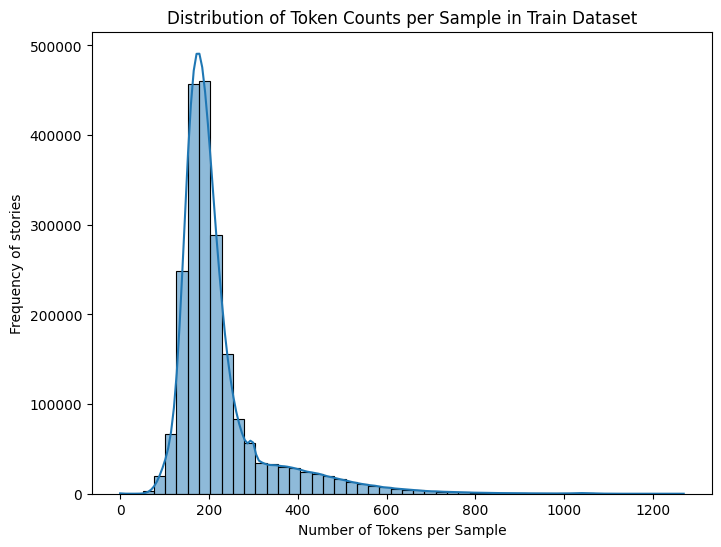

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(tkn_count, bins=50, kde=True,)
plt.xlabel("Number of Tokens per Sample")
plt.ylabel("Frequency of stories")
plt.title("Distribution of Token Counts per Sample in Train Dataset")

In [ ]:
unique_length = np.unique(tkn_count)
print(unique_length[:10])

[ 0  6  9 11 12 13 14 15 17 19]


In [ ]:
length = unique_length[:10]
sample_lengths = defaultdict(int)
max_samples = 10 

for i, toks in enumerate(tkn_train_sample):
   toks_len = len(toks)
   
   if toks_len in length and len(sample_lengths[toks_len]) < max_samples:
      print(f"Sample with {toks_len} tokens: {tokenizer.decode(toks)}")




    

TypeError: object of type 'int' has no len()

In [ ]:

# Target token lengths to inspect
target_lengths = unique_length[:10]
samples_per_length = defaultdict(int)
max_samples = 5

print("🔹 Samples by token length:\n")

for i, toks in enumerate(tkn_train_sample):
    
    toks_len = len(toks)
    
    # Only print if in target lengths and limit not reached
    if toks_len in target_lengths and samples_per_length[toks_len] < max_samples:
        print(f"\nTokens: {toks_len}")
        pprint(dataset["train"][i]["text"])
        samples_per_length[toks_len] += 1
        
        
        samples_per_length[toks_len] += 1

🔹 Samples by token length:


Tokens: 0
''

Tokens: 0
''

Tokens: 0
''

Tokens: 11
'One day a lady entered the room. She was mod'

Tokens: 6
'Once upon a time, there'

Tokens: 11
'Once upon a time, there was a silly little bunny'

Tokens: 9
'Once upon a time, in a quiet little'

Tokens: 17
'Once upon a time, in a big tree, there was a thoughtful raven. The'

Tokens: 13
'Once upon a time, there was a boy named Timmy.'

Tokens: 19
('Once upon a time, there was a little girl named Lily who loved fairies. She '
 'would')

Tokens: 15
'Once upon a time, there was a little girl named Helga. Hel'

Tokens: 11
'Once upon a time, there was a silly little bunny'

Tokens: 12
'Once upon a time, in a wide, hot desert,'

Tokens: 14
'Once upon a time, there was a happy baby named Jack. Jack'

Tokens: 14
'Once upon a time, a chubby cat named Kitty lived in a'


In [ ]:
mean_tokens = np.mean(tkn_count)
median_tokens = np.median(tkn_count)
mode_tokens = Counter(tkn_count).most_common(1)[0][0]

print(f"Average tokens per sample: {mean_tokens:.2f}")
print(f"Median tokens per sample: {median_tokens}")
print(f"Mode tokens: {mode_tokens}")

Average tokens per sample: 222.61
Median tokens per sample: 191.0
Mode tokens: 174


##  **N-gram Analysis (unigram, bigram, trigram)**

In [ ]:
import nltk
from nltk import word_tokenize , sent_tokenize
from nltk.util import ngrams  

#language-specific abbreviation and punctuation data
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    return text.strip()  # Remove leading/trailing whitespace

#counts how many times each n-gram appears in a list of n-grams and returns the most common ones.
def get_top_ngrams(ngrams_list , n=20):
    ngram_freq = Counter(ngrams_list)
    return ngram_freq.most_common(n)


In [ ]:
all_words = []
all_bigrams = []
all_trigrams = []

for sample in tqdm(dataset['validation']):  # Limit for performance (you can increase)
    text = clean_text(sample['text'])
    words = word_tokenize(text)
    all_words.extend(words)
    all_bigrams.extend([' '.join(bg) for bg in ngrams(words, 2)])
    all_trigrams.extend([' '.join(tg) for tg in ngrams(words, 3)])

100%|██████████| 21990/21990 [00:33<00:00, 648.07it/s]


In [ ]:
top_unigrams = get_top_ngrams(all_words)
top_bigrams = get_top_ngrams(all_bigrams)
top_trigrams = get_top_ngrams(all_trigrams)

print("\n🔸 Top 20 Unigrams:")
print(top_unigrams)

print("\n🔸 Top 20 Bigrams:")
print(top_bigrams)

print("\n🔸 Top 20 Trigrams:")
print(top_trigrams)


🔸 Top 20 Unigrams:
[('.', 358849), ('the', 204873), ('and', 181817), (',', 174211), ('to', 129273), ('a', 117121), ('was', 99492), ('he', 81788), ('she', 78131), ('it', 71460), ('they', 64992), ('her', 51001), ("''", 46793), ('``', 46777), ('said', 35139), ('!', 33317), ('his', 33039), ('in', 32774), ('with', 31619), ('lily', 30740)]

🔸 Top 20 Bigrams:
[('. she', 43541), ('. he', 42399), ('. they', 38209), ('. the', 29535), (', ``', 22586), ('was a', 20609), ('. ``', 19850), ('in the', 18923), ('it was', 17512), ('said ,', 17236), ('day ,', 16767), ('one day', 16107), ('. it', 15527), ('to the', 15483), (". ''", 15241), ('there was', 15234), ('. one', 14500), ("! ''", 14025), ('upon a', 13605), ('a time', 13579)]

🔸 Top 20 Trigrams:
[('said , ``', 15326), ('there was a', 14402), ('one day ,', 14009), ('. one day', 13633), ('once upon a', 13545), ('upon a time', 13536), ('a time ,', 10655), (', there was', 10240), ('time , there', 10039), ('and said ,', 7637), ('. it was', 7169), ('was

##  **Extract Most Frequent Token ID**

In [ ]:
# Counter to keep track of token
token_counter = Counter()

# Iterate through all token
for token in tqdm(tkn_train_sample , desc="token_frequecny"):
    token_counter.update(token)

#100 common token 

top_100_token = [token_id for token_id, _ in token_counter.most_common(100)]

# Save file 
with open("top_100_token.text", "w") as f :
    for token_id in top_100_token:
        f.write(f"{token_id}\n")    
print("Top 100 token IDs saved to top_100_token.text")

token_frequecny: 100%|██████████| 2119719/2119719 [01:07<00:00, 31183.52it/s]

Top 100 token IDs saved to top_100_token.text


In [ ]:
#unique token 

print(f" Unique tokens: {len(token_counter)}")

🔹 Unique tokens: 29251


# **Hugging Face Tokenizer**

## **Tokenizer Overview**

### **GPT NEO**

In [23]:
from tokenizers import Tokenizer

In [ ]:
# input 

text = "LLM is the way of connection between human and machine"

# call tolkenizer by searching in Hugging face 
tokenizer = Tokenizer.from_pretrained("KoboldAI/GPT-Neo-125M-AID")

# tokenize the input text
encoded = tokenizer.encode(text)

# print the token IDs , TPKEX
print("Token IDs:", encoded.ids)
print("Tokens:", encoded.tokens)


Token IDs: [3069, 44, 318, 262, 835, 286, 4637, 1022, 1692, 290, 4572]
Tokens: ['LL', 'M', 'Ġis', 'Ġthe', 'Ġway', 'Ġof', 'Ġconnection', 'Ġbetween', 'Ġhuman', 'Ġand', 'Ġmachine']


In [ ]:
tokenizer.decode(encoded.ids)

'LLM is the way of connection between human and machine'

In [ ]:
tokenizer.get_vocab_size()

50257

In [ ]:
tokenizer.get_vocab()

{'ĠInterface': 26491,
 'Ġpractition': 17629,
 '¡': 94,
 'Ġwarm': 5814,
 'REM': 40726,
 'BW': 48802,
 'Ġcurric': 18363,
 'rified': 41301,
 'ĠNational': 2351,
 'tall': 35429,
 'LES': 28378,
 'Ġbadly': 11234,
 'gary': 14849,
 'erial': 48499,
 'ĠSneak': 49475,
 'Ġfathers': 17150,
 'Apps': 48433,
 'ĠAmazing': 23181,
 'ĠDise': 14865,
 'Ġdecoration': 42050,
 'Ġextreme': 3257,
 'Ġencamp': 48020,
 'Ġvill': 4489,
 'Ġmuc': 30322,
 'TH': 4221,
 'Dean': 36372,
 '709': 31495,
 'rb': 26145,
 'Ġexisted': 11196,
 'Ġest': 1556,
 'ĠGAM': 49965,
 'Ġ(~': 31034,
 'ĠCobb': 31868,
 'Ġpesky': 49109,
 'Ġinsane': 13251,
 'Ġplayful': 34264,
 'Ġdeform': 47577,
 'Ġbleak': 30942,
 'Ġopera': 27296,
 'ĠCe': 20101,
 'ĠRebirth': 35538,
 'ĠAssociated': 10575,
 'Ġpride': 11293,
 'Ġsubsistence': 48042,
 'ĠâĨ': 17804,
 'Ġmascul': 18498,
 'Ġfrontline': 44956,
 'Ġpedigree': 46895,
 'Ġminimized': 49491,
 'Ġrg': 48670,
 'ĠNam': 17871,
 'orno': 46447,
 'ĠZap': 36079,
 'Ġmystical': 29746,
 'Ġeman': 31184,
 'MAG': 45820,
 'almost'

In [28]:
# initilazing tokenizer 

tokenizer = Tokenizer(models.BPE(unk_token="|<unk>|"))

NameError: name 'models' is not defined

### **Train tokenizer BEP2**

In [1]:
from tokenizers import Tokenizer , models , pre_tokenizers , trainers


In [30]:
ds = ["Large language models learn patterns in text by training on massive datasets containing books, articles, and code.",
"An LLM predicts the next token in a sequence based on the context of previous tokens.",
"Transformer architectures allow modern language models to capture long-range dependencies in text."]

In [31]:
# create a BPE tokenizer with an unknown token
tokenizer = Tokenizer(models.BPE(unk_token="|<unk>|"))

# Use a pre-tokenizer to split text into words 
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Define Tokenizer Trainer
trainer = trainers.BpeTrainer( vocab_size=100,
                               min_frequency=2,
                               special_tokens=["|<unk>|", "|<pad>|", "|<bos>|", "|<eos>|"])

# Train the tokenizer 
tokenizer.train_from_iterator(ds, trainer=trainer)


tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[{"id":0, "content":"|<unk>|", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":1, "content":"|<pad>|", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":2, "content":"|<bos>|", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}, {"id":3, "content":"|<eos>|", "single_word":False, "lstrip":False, "rstrip":False, "normalized":False, "special":True}], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token="|<unk>|", continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={"|<unk>|":0, "|<pad>|":1, "|<bos>|":2, "|<eos>|":3, ",":4, "-":5, ".":6, "A":7, "L":8, "M":9, "T":10, "a":11, "b":12, "c":13, "d":14, "e":15, "f":16, "g":17, "h":18, "i":19, "k":20, "l":21, "m":22, "n":

In [ ]:
tokenizer.encode("hello world welcome to deep learning world").tokens

['he',
 'l',
 'l',
 'o',
 'w',
 'o',
 'r',
 'l',
 'd',
 'w',
 'e',
 'l',
 'c',
 'o',
 'm',
 'e',
 't',
 'o',
 'de',
 'e',
 'p',
 'l',
 'e',
 'ar',
 'n',
 'ing',
 'w',
 'o',
 'r',
 'l',
 'd']

### **Custom Tokenization for tinyStories**

In [36]:
# create a BPE tokenizer with an unknown token
tokenizer = Tokenizer(models.BPE(unk_token="|<unk>|"))

# Use a pre-tokenizer to split text into words 
# using add prefix text to remove space of start of text
tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space = False)

# Define Tokenizer Trainer
trainer = trainers.BpeTrainer(
    vocab_size=10000,
    min_frequency=2,
    special_tokens=["|<unk>|","<|endoftext|>"]
)

# Train the tokenizer 
tokenizer.train_from_iterator(dataset['train']['text'], trainer=trainer)
eot_id = tokenizer.token_to_id("<|endoftext|>")

# add special token 
tokenizer.post_processor = processors.TemplateProcessing(
    single="<|endoftext|> $A",
    special_tokens=[("<|endoftext|>", eot_id)],
)

# decoder 
tokenizer.decoder = decoders.ByteLevel(add_prefix_space=False)

#save tokenizer 
tokenizer.save("custom_bpe_tokenizer.json")

#print
print(f" tokenizer training complete!")
print(f"vocabulary size: {tokenizer.get_vocab_size()}")

NameError: name 'dataset' is not defined

In [ ]:
sent = "we are going to learn about tokenization"
tokes = tokenizer.encode(sent)
print("Token IDs:", tokes.ids)

NameError: name 'tokenizer' is not defined

In [ ]:
tokens = []
for item in tqdm(dataset["train"]):
    tokens.extend(tokenizer.encode(item["text"]).ids)

torch.save(torch.LongTensor(tokens), "train_tokens-10K.pt")

100%|██████████| 2119719/2119719 [20:18<00:00, 1739.01it/s]


In [ ]:
tokens = []
for item in tqdm(dataset["validation"]):
    tokens.extend(tokenizer.encode(item["text"]).ids)

torch.save(torch.LongTensor(tokens), "validation_tokens-10K.pt")

100%|██████████| 21990/21990 [00:11<00:00, 1880.23it/s]


# **Datasets**

## **Utils**

In [4]:
def preapare_data (tokens , seq_length):
    # convert flat list to 2D tokens
    # number of token in list 
    # Desired sequ lenght 

    n_token = (tokens.shape[0] // seq_length) * seq_length
    tokens = tokens[:n_token]

    # convert to 2D 

    return tokens.view(-1 , seq_length)
    

### **TensorDataset / Class**

In [2]:
# load 10K tokenizer 

tokenize_train_sample = torch.load(r'D:\Pytorch-Project\LLM_Class\train_tokens-10K.pt')
tokenize_valid_sample = torch.load(r'D:\Pytorch-Project\LLM_Class\validation_tokens-10K.pt')

In [9]:
tokenize_train_sample.shape , tokenize_valid_sample.shape

(torch.Size([464965814]), torch.Size([4673588]))

In [5]:
seq_length = 128
tokenized_train_sample = preapare_data(tokenize_train_sample , seq_length)
tokenized_train_sample.shape 


torch.Size([3632545, 128])

In [ ]:
tokenized_train_sample


tensor([[   1,  316,  252,  ...,  325, 2394,  161],
        [1656,  652,  468,  ...,  159, 1402, 1438],
        [ 241,  330,   15,  ...,  231,  719,  319],
        ...,
        [  15,  338,  178,  ...,  248,  375,   15],
        [ 402,  252,   13,  ...,  155,  293,  342],
        [ 396,  735,   15,  ...,  300,  482,   15]])

In [ ]:
x = tokenized_train_sample[:10 , :-1]
y = tokenized_train_sample[:10 , 1:]
train_set = TensorDataset(x ,y)
train_set[0]

(tensor([   1,  316,  252,   13,  155,  293,  342,  396,  260,  491,  155, 3628,
          212,  205,  654,   15,  209,  599,  200,  178, 2858,  162,  255,  238,
          200,  683,  200,  178, 2012,   15,  260,  340,  162,  844,  159, 3628,
          238,  205,  261,   13,  246,  234,  356, 5090,  155, 2120,  241,  205,
         2392,   15,  132,  132,  239,  364,  162,  205,  261,  161,  223,   13,
          225,  666,   13,  231,  491,  636, 3628,   15, 1176,  242,  844,  200,
          238,  414,  161, 5090,  547, 2392,  373,  761,  261,  394,  161,  223,
           13,  225,  727,   13,  260,   13,  259,  367,  844,  159, 3628,  161,
         1200,  522, 2392,  311,  132,  132, 4517,   13,  258, 1550,  159, 3628,
          161, 7822,  159, 2120,  241,  260,  267, 2392,   15,  305,  178,  281,
         2858,  262,  344,  683,  258,  325, 2394]),
 tensor([ 316,  252,   13,  155,  293,  342,  396,  260,  491,  155, 3628,  212,
          205,  654,   15,  209,  599,  200,  178, 2858,

In [ ]:
train_set = TensorDataset(tokenized_train_sample[: , :-1],tokenized_train_sample[: , 1:])

In [ ]:
train_iter = next(iter(train_set))
train_iter.

AttributeError: 'NoneType' object has no attribute 'data'

In [6]:
class tinystoriesDataset(Dataset):

    def __init__(self, data, seq_length):

        self.seq_length = seq_length
        self.data = preapare_data(data , seq_length+1)
        
    def __len__(self):

        return self.data.shape[0]
    
    # define x_train , y_train 
    def __getitem__(self, idx):

        sample = self.data[idx]
        return sample[:-1], sample[1:]



In [36]:
train_set = tinystoriesDataset(tokenize_train_sample, 128)
train_set.data.shape , len(train_set) , train_set[0]

(torch.Size([3604386, 129]),
 3604386,
 (tensor([   1,  316,  252,   13,  155,  293,  342,  396,  260,  491,  155, 3628,
           212,  205,  654,   15,  209,  599,  200,  178, 2858,  162,  255,  238,
           200,  683,  200,  178, 2012,   15,  260,  340,  162,  844,  159, 3628,
           238,  205,  261,   13,  246,  234,  356, 5090,  155, 2120,  241,  205,
          2392,   15,  132,  132,  239,  364,  162,  205,  261,  161,  223,   13,
           225,  666,   13,  231,  491,  636, 3628,   15, 1176,  242,  844,  200,
           238,  414,  161, 5090,  547, 2392,  373,  761,  261,  394,  161,  223,
            13,  225,  727,   13,  260,   13,  259,  367,  844,  159, 3628,  161,
          1200,  522, 2392,  311,  132,  132, 4517,   13,  258, 1550,  159, 3628,
           161, 7822,  159, 2120,  241,  260,  267, 2392,   15,  305,  178,  281,
          2858,  262,  344,  683,  258,  325, 2394,  161]),
  tensor([ 316,  252,   13,  155,  293,  342,  396,  260,  491,  155, 3628,  212,

In [7]:
train_set = tinystoriesDataset(tokenize_train_sample , seq_length=128)
valid_set = tinystoriesDataset(tokenize_valid_sample , seq_length=128)
print(f' train {len(train_set):,}')
print(f' valid {len(valid_set):,}')

 train 3,604,386
 valid 36,229


## **Other Method**

### Iterable Datasets 

In [ ]:
class TinyStoriesDataset(IterableDataset):
    def __init__(self, text_samples , tokenizer , group_size = 10 , seq_len = 256 ):
        """
            Args : text_sample (raw data includes all texts)
                    tokenizer (create tokenizer here)
                    group_size = number of text sample per chunk before tokenizer 
                    seq_len = 
        """
        self.text_samples = text_samples
        self.tokenizer = tokenizer 
        self.group_size = group_size
        self.seq_len = seq_len
        
    def __iter__(self):
        buffer = []

        # iterate through datasets 
        for i in range(0, len(self.text_samples), self.group_size):
            sample = ' <|endoftext|>'.join(self.text_samples[i:i + self.group_size]) +' <|endoftext|>'
            tokens = self.tokenizer.encode(sample).ids
            buffer += tokens

            yield from(
                torch.from_numpy(np.array(buffer[j:j + self.seq_len + 1], dtype=np.int64))
                for j in range(0 , len(buffer)-self.seq_len, self.seq_len)
            )
        
        3.0
            buffer = buffer[(len(buffer) // self.seq_len) * self.seq_len:]

# **DataLoader**

In [8]:
batch_size = 64

train_loader = DataLoader(train_set, batch_size=batch_size , shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size , shuffle=True, pin_memory=True)

print(f'train_batch {len(train_loader):,}')
print(f'valid_batch {len(valid_loader):,}')


train_batch 56,319
valid_batch 567


In [9]:
x_batch , y_batch = next(iter(train_loader))
x_batch.shape , y_batch.shape        

(torch.Size([64, 128]), torch.Size([64, 128]))

In [44]:
len(train_loader) , len(valid_loader)

(56319, 567)

In [45]:
%timeit next(iter(train_loader))

279 ms ± 16.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
iter_train = iter(train_loader)

In [14]:
%timeit next(iter_train)

387 μs ± 15.1 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


# **GPT MODEL**

## **IMPORT**

In [10]:
import time
import torch 
from torch import nn
from torch.utils.data import dataloader , Dataset
from torch.nn import functional as F
from tokenizers import Tokenizer
from dataclasses import dataclass

## **UTILS**

In [11]:
def num_trainable_params(model):
    nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
    return nums

In [12]:
def calculate_time(model, x, num_runs=10):
    torch.cuda.synchronize()
    start = time.time()
    for _ in range (num_runs):
        model(*x)
    torch.cuda.synchronize()
    return (time.time()-start) / num_runs

## **INIT**

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## **MODEL**

### **GPT**

In [14]:
@dataclass
class GPTConfig:
    vocab_size: int = 50257
    seq_len: int = 1024
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    f_expnd: int = 4

    @property
    def f_forward(self):
        return self.n_embd * self.f_expnd
    
config = GPTConfig()

In [15]:
class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config
        
        # token & positional embeddings
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)
        self.wpe = nn.Embedding(config.seq_len, config.n_embd)
        
        # use TransformerEncoderLayer instead
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=config.n_embd,
            nhead=config.n_head,             
            dim_feedforward=config.f_forward,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        # stack encoder layers (GPT-style)
        self.decoders = nn.TransformerEncoder(
            encoder_layer,
            num_layers=config.n_layer
        )
        
        # final norm + linear head
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # adding mask for causal attention
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(config.seq_len, config.seq_len), diagonal=1).bool()
        )           

        
    def forward(self , idx):
        B, T = idx.shape
        
        pos = torch.arange(T, device=idx.device).unsqueeze(0)

        x = self.wte(idx) + self.wpe(pos)

        mask = self.mask[:T, :T]

        #apply transformer
        #     
        x = self.decoders(x, mask=mask)
        x =  self.ln_f(x)
        logits = self.lm_head(x)
        return logits


In [16]:
model = GPT(config)
model.to(device)




c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


GPT(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (decoders): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=3072, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=3072, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [17]:
num_trainable_params(model) , num_trainable_params(model.decoders) 

(163.037184, 85.054464)

In [18]:
model = GPT(GPTConfig(
    vocab_size=10_000,
    seq_len= 256,
    n_layer=4,
    n_head=4,
    n_embd=256
))
model.to(device)

print(f'trainable_parameter{num_trainable_params (model)} :')
print(model)

trainable_parameter8.345088 :
GPT(
  (wte): Embedding(10000, 256)
  (wpe): Embedding(256, 256)
  (decoders): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=10000, bias=False)
)


# **Train/Eval Pilot**

In [19]:
y = model(x_batch.to(device))
y.shape



torch.Size([64, 128, 10000])

In [31]:
y[0,0]
print(y.max())
print(y.min())

tensor(3.4679, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-3.2499, device='cuda:0', grad_fn=<MinBackward1>)


(array([1.000000e+00, 4.000000e+00, 1.700000e+01, 6.700000e+01,
        1.990000e+02, 5.780000e+02, 1.485000e+03, 3.853000e+03,
        9.464000e+03, 2.154400e+04, 4.725400e+04, 9.678500e+04,
        1.882890e+05, 3.460170e+05, 6.013730e+05, 9.938250e+05,
        1.545984e+06, 2.278468e+06, 3.182097e+06, 4.207384e+06,
        5.263679e+06, 6.246913e+06, 7.027445e+06, 7.483619e+06,
        7.563654e+06, 7.234120e+06, 6.561800e+06, 5.647473e+06,
        4.601023e+06, 3.550928e+06, 2.597404e+06, 1.801436e+06,
        1.180296e+06, 7.339260e+05, 4.287530e+05, 2.373710e+05,
        1.244660e+05, 6.131200e+04, 2.864700e+04, 1.260800e+04,
        5.203000e+03, 2.021000e+03, 7.800000e+02, 2.940000e+02,
        1.050000e+02, 2.300000e+01, 1.000000e+01, 2.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([-3.2499187 , -3.11556315, -2.98120737, -2.84685183, -2.71249628,
        -2.57814074, -2.44378519, -2.30942941, -2.17507386, -2.04071832,
        -1.90636265, -1.77200699, -1.63765144, -

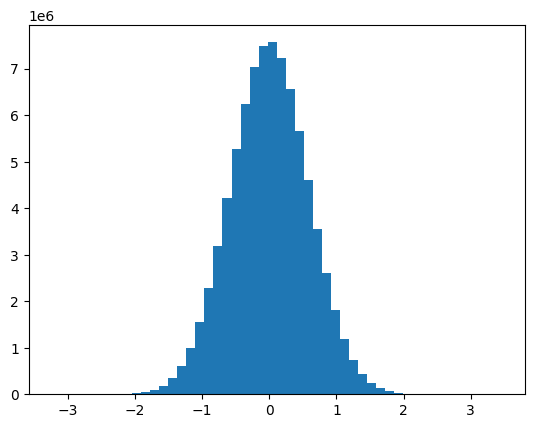

In [28]:
# 1-model initilizing 
logits = model(x_batch.to(device))
# 2- Loss caculation 
loss = F.cross_entropy((logits.view(-1 , logits.shape[-1])),(y_batch.flatten().to(device).long()))
# 3- Loss Backward 
loss.backward()
# 4- Otimization (updatae step , remove gradient)
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
optimizer.step()
optimizer.zero_grad()

In [56]:
# turn on mode to use all aspects of components 
model.train()

for iter, (x_batch,y_batch) in enumerate (train_loader): 
    # 1-model initilizing 
    logits = model(x_batch.to(device))
    # 2- Loss caculation 
    loss = F.cross_entropy((logits.view(-1 , logits.shape[-1])),(y_batch.flatten().to(device).long()))
    print(loss.item())
    # 3- Loss Backward 
    loss.backward()
    # 4- Otimization (updatae step , remove gradient)
    optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
    optimizer.step()
    optimizer.zero_grad()
    if iter > 100 :
        break


4.211667537689209
4.161276340484619
4.1913042068481445
4.192999839782715
4.169422626495361
4.411157608032227
4.263978004455566
4.035041809082031
4.285825252532959
4.213990211486816
4.206351280212402
4.160485744476318
4.119015216827393
4.076995849609375
4.2632317543029785
4.186963081359863
4.185256004333496
4.243740558624268
4.081958770751953
4.226246356964111
4.087390422821045
4.232897758483887
4.092369079589844
4.262111663818359
4.145956516265869
4.1503400802612305
4.142977714538574
4.125945568084717
4.14627742767334
4.198744773864746
4.068408489227295
4.130714416503906
4.076929092407227
4.1139678955078125
4.118677616119385
4.078634738922119
4.1770195960998535
4.006381034851074
4.1809282302856445
4.127403259277344
4.050136089324951
4.083784580230713
4.06235408782959
4.103094577789307
4.142763137817383
4.152168273925781
4.026351451873779
4.2025651931762695
4.151370048522949
4.085300922393799
4.060599327087402
3.9405994415283203
4.197178840637207
4.061000823974609
4.078628063201904
4.17

## **Evaluation**

In [57]:
model.eval()
with torch.no_grad():
    for iter, (x_batch,y_batch) in enumerate (valid_loader): 
        # 1-model initilizing 
        logits = model(x_batch.to(device))
        # 2- Loss caculation 
        loss = F.cross_entropy((logits.view(-1 , logits.shape[-1])),(y_batch.flatten().to(device).long()))
        print(loss.item())
        if iter > 10 :
            break

4.00053596496582
4.0410614013671875
3.9110240936279297
4.126372814178467
3.8846848011016846
3.985438823699951
4.018726825714111
4.008582592010498
3.895753860473633
3.981395721435547
4.088736534118652
3.964210033416748


In [33]:
torch.cuda.empty_cache()

In [37]:

print(y.shape)
print(y[0,0])
y[0,0].softmax(dim=0)

print(y_batch.shape)



torch.Size([64, 128, 10000])
tensor([ 1.0101, -0.4375, -0.1949,  ...,  0.4130, -0.1802, -0.4988],
       device='cuda:0', grad_fn=<SelectBackward0>)
torch.Size([64, 128])


In [53]:
# loss = nn.CrossEntropyLoss()
#CrossEntropyLoss expect a 2D tensor where:
   # |_dimension 0 = all tokens in the batch collapsed
   # |_dimension 1 = vocabulary logits

print (y.view(-1 , y.shape[-1]).shape)
print (y_batch.flatten().shape)

loss = F.cross_entropy((logits.view(-1 , logits.shape[-1])),(y_batch.flatten().to(device).long()))
loss

torch.Size([8192, 10000])
torch.Size([8192])


tensor(9.3474, device='cuda:0', grad_fn=<NllLossBackward0>)

In [54]:
loss.backward()

In [55]:
optimizer = torch.optim.AdamW(model.parameters(), lr = 1e-3)
optimizer.step()
optimizer.zero_grad()

# **Generate Text**

In [21]:
tokenizer = Tokenizer.from_file("custom_bpe_tokenizer.json")

In [58]:
max_seq_len = 128
Prompt = "In early morning"
tokes = tokenizer.encode(Prompt).ids
tokes = torch.tensor(tokes , dtype=torch.int32 , device=device).unsqueeze(0)

model.eval()
with torch.inference_mode():
    for i in range(max_seq_len):
        logits = model(tokes)
        scores = logits[0, [-1]].softmax(dim = -1)
        idx = scores.argmax(keepdims=True)
        tokes = torch.concat((tokes , idx) , dim=-1)


tokes , tokenizer.decode(tokes[0].tolist())

(tensor([[   1, 2201, 3450, 1413,   13,  155,  302,   13,  155,  302,   13,  155,
           302,   13,  155,  302,   13,  155,  302,   13,  155,  302,   13,  155,
           302,   13,  155,  302,   13,  155,  302,   13,  155,  293,  342,  396,
           260,   15,  209,  399,  162,  255,  238,  205,  261,  161,  205,  261,
           161,  205,  261,   15,  209,  178,  284,  300,  161,  205,  261,   15,
           209,  178,  284,  300,  161,  205,  261,  161,  205,  261,  161,  205,
           261,   15,  209,  178,  284,  300,   15,  209,  223,   13,  225,   42,
           681,  612,   13,  260,   13,  260,   15,  231,  551,  379,  242,   13,
           260,   15,  231,  551,  379,  242,   13,  260,   15,  451,  336,  284,
           300,   15,  451,  336,  284,  300,   15,  451,  336,  284,  300,   15,
           451,  336,  284,  300,   15,  451,  336,  284,  300,   15,  451,  336]],
        device='cuda:0'),
 'In early morning, a big, a big, a big, a big, a big, a big, a big, a

In [47]:
tokenizer.decode([13])

','

In [ ]:
scores = logits[0, [-1]].softmax(dim = -1)
scores

tensor([[-7.1718, -2.1461, -0.3694,  ..., -6.7578, -6.7868, -6.5921]],
       device='cuda:0')